In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
from src.models import gradcam2

from tqdm.notebook import tqdm
from src.data.datasets import Scoring, ScoringTest
from src.models.train import AsparagusScoring
from sklearn.metrics import r2_score

In [2]:
# With maskout
checkpoint = '/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/checkpoints/os_maskout/cp_epoch=22_val_loss=0.062_val_R2=0.865.ckpt'
checkpoint1 = '/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/checkpoints/maskout_6/cp_epoch=39_val_loss=0.005_val_R2=0.902.ckpt'
# Raw
checkpoint2 = '/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/checkpoints/no_maskout_8/cp_epoch=10_val_loss=0.005_val_R2=0.901.ckpt' 
# No maskout
checkpoint3 = '/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/checkpoints/os_raw/cp_epoch=10_val_loss=0.060_val_R2=0.874.ckpt'
# Denoised with maskout
checkpoint4 = '/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/checkpoints/os_desoised_maskout/cp_epoch=16_val_loss=0.060_val_R2=0.871.ckpt'

In [18]:
system = AsparagusScoring.load_from_checkpoint(checkpoint)
hparams = system.hparams
device = torch.device('cuda:0')
system.freeze()
# system = system.to(device)
gr = gradcam2.GradCAM(system)

In [19]:
hparams

Namespace(alpha=0.2, augmentation='light', batch_size=96, checkpoints_path='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/checkpoints/', es_patience=11, experiment_name='asparagus_scoring', freeze=False, gpus=[0, 1], images_dir='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/images/', labels='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/splits/LABELS.txt', labels_file='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/annotations.csv', load_checkpoint_file=None, lr=0.0001, lr_end=1e-06, mask_dir='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/masks/', maskout=True, max_epochs=500, max_grad_norm=10.0, mixup=False, mode='pad', model_hyperparams={'encoder_class': 'pretrainedmodels.se_resnext101_32x4d', 'encoder_hyperparams': {'pretrained': 'imagenet'}, 'num_input': 1000, 'num_output': 1}, n_checkpoints=1, note='', num_workers=12, optimizer='adam', run_name='os_m

In [20]:
# dataset = ScoringTest(size=hparams.size,
#                       mode=hparams.mode,
#                       images_dir='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/images/',
#                       maskout=hparams.maskout)
names = np.loadtxt('/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/splits/VAL.txt', dtype=str)
dataset = Scoring(names=names,
                  labels_file='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/annotations.csv',
                  size=hparams.size,
                  mode=hparams.mode,
                  images_dir='/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/images/',
                  maskout=hparams.maskout)

In [21]:
input_img, score = dataset[1]
input_img = input_img.unsqueeze(0)
pred = system(input_img)
input_img.requires_grad = True
probs, ids = gr.forward(input_img)
gr.backward(ids=torch.tensor([[0]]))#.to(device))

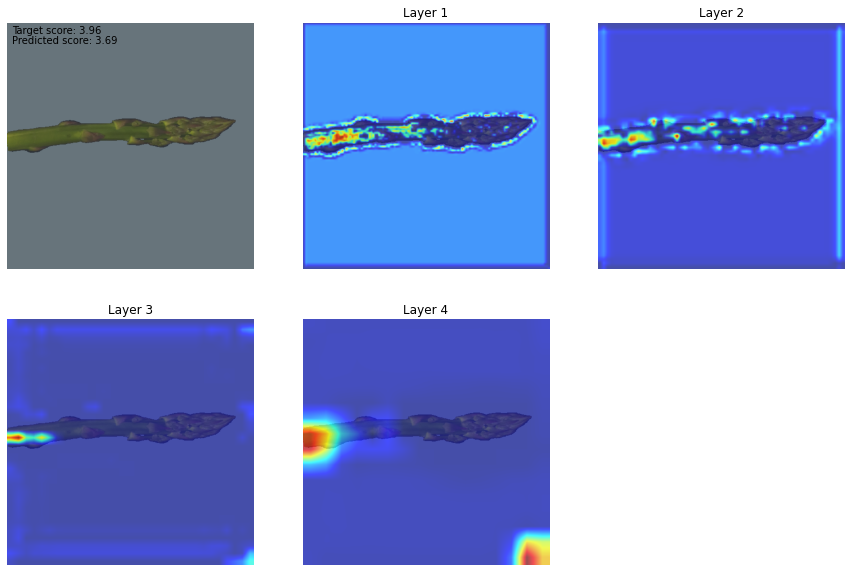

In [17]:
# maskout gradcam visualization from checkpoint1
# model does have a layer 0, so index starts from 1.

mean=(0.485, 0.456, 0.406)
std=(0.229, 0.224, 0.225)
img = np.moveaxis(input_img.detach().cpu().numpy()[0], 0, 2)
img = 255*(img * std + mean)
img = img[:, :, ::-1].astype(int)

fig, axs = plt.subplots(2, 3, figsize=(15,10), squeeze=False)
ind = 1
for i in range(2):
    for j in range(3):
        if (i == 0) & (j==0):
            axs[0][0].imshow(img)
            axs[0][0].axis('off')
            axs[0][0].text(10, 22, f'Target score: {round(score.item(),2) * 9}')
            axs[0][0].text(10, 42, f'Predicted score: {round(pred.item(),2) * 9}')
        elif ind >= 5:
            axs[1][2].set_axis_off()
            break
        else:
            regions = gr.generate(target_layer='model.encoder.layer' + str(ind))
            mask = regions[0][0].detach().cpu().numpy()
            heatmap = cv2.applyColorMap(np.uint8(255 - 255 * mask), cv2.COLORMAP_JET)
            heatmap = np.float32(heatmap) 
            cam = heatmap + np.float32(img) 
            cam = cam / np.max(cam)
            axs[i][j].imshow(cam, cmap='jet', alpha=1)
            axs[i][j].axis('off')
            axs[i][j].set_title('Layer '+str(ind))
            ind += 1

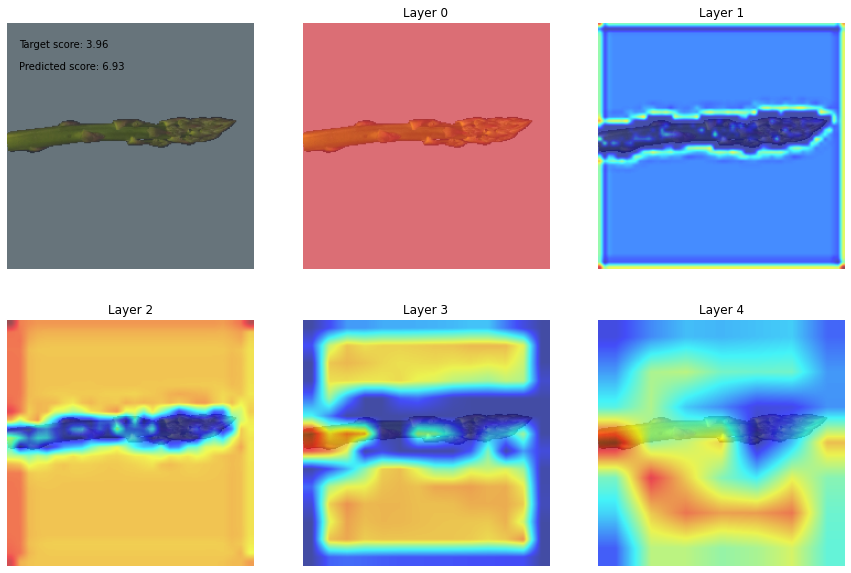

In [22]:
# os_maskout gradcam visualization from checkpoint

mean=(0.485, 0.456, 0.406)
std=(0.229, 0.224, 0.225)
img = np.moveaxis(input_img.detach().cpu().numpy()[0], 0, 2)
img = 255*(img * std + mean)
img = img[:, :, ::-1].astype(int)

fig, axs = plt.subplots(2, 3, figsize=(15,10), squeeze=False)
ind = 0
for i in range(2):
    for j in range(3):
        if (i == 0) & (j==0):
            axs[0][0].imshow(img)
            axs[0][0].axis('off')
            axs[0][0].text(10, 22, f'Target score: {round(score.item(), 2) * 9}')
            axs[0][0].text(10, 42, f'Predicted score: {round(pred.item(), 2) * 9}')
        else:
            regions = gr.generate(target_layer='model.encoder.layer' + str(ind))
            mask = regions[0][0].detach().cpu().numpy()
            heatmap = cv2.applyColorMap(np.uint8(255 - 255 * mask), cv2.COLORMAP_JET)
            heatmap = np.float32(heatmap) 
            cam = heatmap + np.float32(img) 
            cam = cam / np.max(cam)
            axs[i][j].imshow(cam, cmap='jet', alpha=1)
            axs[i][j].axis('off')
            axs[i][j].set_title('Layer '+str(ind))
            ind += 1

### Iteratively generate all Grad CAM results

In [9]:
file = open('/mnt/QUANTGEN/SRCDATA/DL/asparagus_head_scoring/training_data/scoring/combined/splits/VAL.txt', 'r') 
lines = file.readlines()
file_name = []
for line in lines: 
    line = line.rstrip()
    file_name.append(line)

In [10]:
save_dir1 = os.getcwd() + '/Grad_CAM_Maskout/'
save_dir2 = os.getcwd() + '/Grad_CAM_Denoised_NoMask/'
save_dir3 = os.getcwd() + '/Grad_CAM_Raw/'
save_dir4 = os.getcwd() + '/Grad_CAM_Denoised/'

print(save_dir1)

/home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Maskout/


In [11]:
idx=0

for input_img, score in tqdm(dataset):
    input_img = input_img.unsqueeze(0)
    pred = system(input_img)
    input_img.requires_grad = True
    probs, ids = gr.forward(input_img)
    gr.backward(ids=torch.tensor([[0]]))
    
    mean=(0.485, 0.456, 0.406)
    std=(0.229, 0.224, 0.225)
    img = np.moveaxis(input_img.detach().cpu().numpy()[0], 0, 2)
    img = 255*(img * std + mean)
    img = img[:, :, ::-1].astype(int)
    fig, axs = plt.subplots(2, 3, figsize=(15,10), squeeze=False)
    ind = 1
    
    # Plot figure 
    for i in range(2):
        for j in range(3):
            if (i == 0) & (j==0):
                axs[0][0].imshow(img)
                axs[0][0].axis('off')
                axs[0][0].text(10, 22, f'Target score: {round(score.item(),2) * 9}')
                axs[0][0].text(10, 42, f'Predicted score: {round(pred.item(),2) * 9}')
            
            elif ind >= 5:
                axs[1][2].set_axis_off()
                break    
            
            else:
                regions = gr.generate(target_layer='model.encoder.layer'+str(ind))
                mask = regions[0][0].detach().cpu().numpy()
                heatmap = cv2.applyColorMap(np.uint8(255 - 255 * mask), cv2.COLORMAP_JET)
                heatmap = np.float32(heatmap) 
                cam = heatmap + np.float32(img) 
                cam = cam / np.max(cam)
                axs[i][j].imshow(cam, cmap='jet', alpha=1)
                axs[i][j].axis('off')
                axs[i][j].set_title('Layer '+str(ind))
                ind += 1
    
    # Save the plot figure 
    plt.savefig(save_dir2 + file_name[idx])
    plt.close()
    idx += 1

  0%|          | 0/310 [00:00<?, ?it/s]

In [12]:
!zip -r Asparagus_Grad_CAM_Denoised_NoMask /home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/

  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/ (stored 0%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set4_41_004_ill_H2.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set2_22_037_ill_H5.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set2_13_034_ill_H3.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set4_74_019_ill_H1.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set3_37_011_ill_H1.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set5_68_003_ill_H1.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set3_09_005_ill_H5.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set2_50_008_ill_H

  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set5_84_010_ill_H1.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set5_10_005_ill_H1.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set4_50_012_ill_H1.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set2_87_028_ill_H3.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set2_10_003_ill_H3.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set5_11_013_ill_H7.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set3_26_004_ill_H5.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set4_00_025_ill_H6.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_

  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set5_92_028_ill_H5.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set3_94_030_ill_H3.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set2_99_018_ill_H4.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set2_76_011_ill_H4.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set3_36_008_ill_H8.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set5_17_034_ill_H3.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set2_24_004_ill_H1.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set2_08_036_ill_H5.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_

  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set2_31_018_ill_H2.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set2_91_016_ill_H10.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set5_82_033_ill_H6.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set3_39_028_ill_H7.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set4_36_003_ill_H5.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set5_43_009_ill_H1.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set4_57_018_ill_H4.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set4_46_026_ill_H2.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised

  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set2_61_025_ill_H2.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set4_30_021_ill_H4.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set3_19_029_ill_H3.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set2_95_033_ill_H7.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set4_25_017_ill_H6.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set4_28_025_ill_H8.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set5_79_031_ill_H2.png (deflated 2%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_NoMask/set5_56_018_ill_H1.png (deflated 1%)
  adding: home/SOKI/ImageFiles/asparagus_head_scoring/Grad_CAM_Denoised_

In [10]:
val_loader = system.val_dataloader()
system.freeze()
targets = []
preds = []
device = torch.device('cuda:0')
system = system.to(device)
with torch.no_grad():
    for batch in tqdm(val_loader):
        x, y = batch
        x = x.to(device)
        targets.extend(y.flatten().cpu().tolist())
        out = system(x)
        preds.extend(out.flatten().cpu().tolist())
predictions = np.array(preds)
targets = np.array(targets)

names = system.val_dataloader().dataset.names

  0%|          | 0/39 [00:00<?, ?it/s]

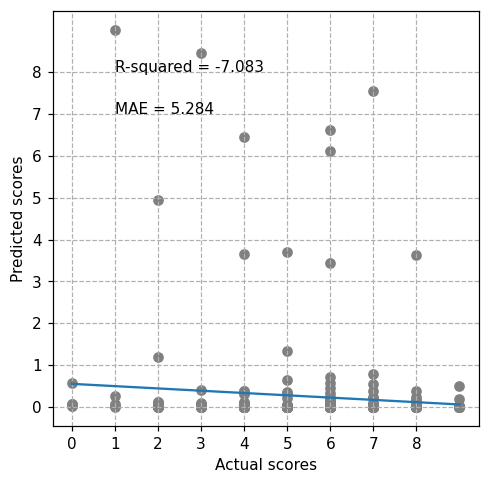

In [11]:
df = pd.DataFrame(columns=['NAME', 'PREDICTION', 'TARGETS', 'ERROR'])
df['NAME'] = names
df['PREDICTION'] = [round(p*9, 2) for p in predictions]
df['TARGETS'] = [round(t*9, 2) for t in targets]
df['ERROR'] = [round(abs(t-p)*9, 2) for t,p in zip(targets, predictions)]
r2 = r2_score(targets, predictions)
mae = df['ERROR'].mean()

targets = df['ANNOTATION'].tolist()
predictions = df['PREDICTION'].tolist()
plt.figure(figsize=(5,5), dpi=110)
plt.scatter(targets, predictions, c='grey')
plt.xlabel('Actual scores')
plt.ylabel('Predicted scores')
plt.grid(linestyle='--')
plt.plot(np.unique(targets), np.poly1d(np.polyfit(targets, predictions, 1))(np.unique(targets)))
plt.xticks(ticks=np.arange(0,9,1), labels=np.arange(0,10,1))
plt.yticks(ticks=np.arange(0,9,1), labels=np.arange(0,10,1))

plt.text(1, 8, 'R-squared = %0.3f' % r2)
plt.text(1, 7, 'MAE = %0.3f' % mae)
plt.show()